In [2]:
import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.datasets import CocoDetection
from torchvision.transforms import functional as F
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from PIL import Image

In [3]:
# Define transformations
class CocoTransform:
    def __call__(self, image, target):
        image = F.to_tensor(image)  # Convert PIL image to tensor
        return image, target

In [4]:
# Dataset class
def get_coco_dataset(img_dir, ann_file):
    return CocoDetection(
        root=img_dir,
        annFile=ann_file,
        transforms=CocoTransform()
    )

# Load datasets
train_dataset = get_coco_dataset(
    img_dir="C:/Users/User/dataset/train",
    ann_file="C:/Users/User/dataset/train/annotations/_annotations.coco.json"
)


val_dataset = get_coco_dataset(
    img_dir="C:/Users/User/dataset/valid",
    ann_file="C:/Users/User/dataset/valid/annotations/_annotations.coco.json"
)



# DataLoader
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

loading annotations into memory...
Done (t=0.10s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


In [5]:
# Load Faster R-CNN with ResNet-50 backbone
def get_model(num_classes):
    # Load pre-trained Faster R-CNN
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
    
    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    
    # Replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

In [6]:
# Initialize the model
num_classes = 2 # Background + fish
model = get_model(num_classes)

C:\Users\User\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:
# Move model to GPU if available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

# Define optimizer and learning rate scheduler
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.002, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [7]:
def train_one_epoch(model, optimizer, data_loader, device, epoch):
    model.train()
    for images, targets in data_loader:
        # Move images to the device
        images = [img.to(device) for img in images]

        # Validate and process targets
        processed_targets = []
        valid_images = []
        for i, target in enumerate(targets):
            boxes = []
            labels = []
            for obj in target:
                # Extract bbox
                bbox = obj["bbox"]  # Format: [x, y, width, height]
                x, y, w, h = bbox

                # Ensure the width and height are positive
                if w > 0 and h > 0:
                    boxes.append([x, y, x + w, y + h])  # Convert to [x_min, y_min, x_max, y_max]
                    labels.append(obj["category_id"])

            # Only process if there are valid boxes
            if boxes:
                processed_target = {
                    "boxes": torch.tensor(boxes, dtype=torch.float32).to(device),
                    "labels": torch.tensor(labels, dtype=torch.int64).to(device),
                }
                processed_targets.append(processed_target)
                valid_images.append(images[i])  # Add only valid images

        # Skip iteration if no valid targets
        if not processed_targets:
            continue

        # Ensure images and targets are aligned
        images = valid_images

        # Forward pass
        loss_dict = model(images, processed_targets)
        losses = sum(loss for loss in loss_dict.values())

        # Backpropagation
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

    print(f"Epoch [{epoch}] Loss: {losses.item():.4f}")

In [10]:
# Training loop
num_epochs = 100
for epoch in range(num_epochs):
    train_one_epoch(model, optimizer, train_loader, device, epoch)
    lr_scheduler.step()
    
    # Save the model's state dictionary after every epoch
    model_path = f"C:/Users/User/fasterrcnn_result/fasterrcnn_resnet50_epoch_{epoch + 1}.pth"
    torch.save(model.state_dict(), model_path)
    print(f"Model saved: {model_path}")

Epoch [0] Loss: 0.4790
Model saved: C:/Users/User/fasterrcnn_result/fasterrcnn_resnet50_epoch_1.pth
Epoch [1] Loss: 0.4466
Model saved: C:/Users/User/fasterrcnn_result/fasterrcnn_resnet50_epoch_2.pth
Epoch [2] Loss: 0.2961
Model saved: C:/Users/User/fasterrcnn_result/fasterrcnn_resnet50_epoch_3.pth
Epoch [3] Loss: 0.2631
Model saved: C:/Users/User/fasterrcnn_result/fasterrcnn_resnet50_epoch_4.pth
Epoch [4] Loss: 0.2922
Model saved: C:/Users/User/fasterrcnn_result/fasterrcnn_resnet50_epoch_5.pth
Epoch [5] Loss: 0.4285
Model saved: C:/Users/User/fasterrcnn_result/fasterrcnn_resnet50_epoch_6.pth
Epoch [6] Loss: 0.2507
Model saved: C:/Users/User/fasterrcnn_result/fasterrcnn_resnet50_epoch_7.pth
Epoch [7] Loss: 0.3918
Model saved: C:/Users/User/fasterrcnn_result/fasterrcnn_resnet50_epoch_8.pth
Epoch [8] Loss: 0.3159
Model saved: C:/Users/User/fasterrcnn_result/fasterrcnn_resnet50_epoch_9.pth
Epoch [9] Loss: 0.3266
Model saved: C:/Users/User/fasterrcnn_result/fasterrcnn_resnet50_epoch_10.pth

In [22]:
import os
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.transforms import functional as F
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from torchvision.datasets.coco import CocoDetection
from torchvision.models.detection.transform import GeneralizedRCNNTransform
from tqdm import tqdm

# --- Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint_dir = "C:/Users/User/fasterrcnn_result"
ann_file = "C:/Users/User/dataset/valid/annotations/_annotations.coco.json"
img_dir = "C:/Users/User/dataset/valid"

# --- Load validation dataset ---
class CocoDataset(CocoDetection):
    def __getitem__(self, idx):
        img, target = super().__getitem__(idx)
        image_id = self.ids[idx]
        ann_ids = self.coco.getAnnIds(imgIds=image_id)
        anns = self.coco.loadAnns(ann_ids)

        # Convert to required format
        boxes = []
        labels = []
        for obj in anns:
            x, y, w, h = obj["bbox"]
            boxes.append([x, y, x + w, y + h])
            labels.append(obj["category_id"])

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor([image_id])
        }
        return F.to_tensor(img), target

val_dataset = CocoDataset(img_dir, ann_file)
coco_gt = val_dataset.coco

# --- Model loader ---
def get_model(num_classes):
    model = fasterrcnn_resnet50_fpn(pretrained=False, num_classes=num_classes)
    return model

# --- COCO evaluation function ---
def coco_eval(model, dataset, coco_gt):
    model.eval()
    results = []
    with torch.no_grad():
        for img, target in tqdm(dataset, desc="Evaluating"):
            img = img.to(device)
            pred = model([img])[0]

            image_id = int(target["image_id"])
            boxes = pred["boxes"].cpu().numpy()
            scores = pred["scores"].cpu().numpy()
            labels = pred["labels"].cpu().numpy()

            for box, score, label in zip(boxes, scores, labels):
                x_min, y_min, x_max, y_max = box
                results.append({
                    "image_id": image_id,
                    "category_id": int(label),
                    "bbox": [x_min, y_min, x_max - x_min, y_max - y_min],
                    "score": float(score),
                })

    coco_dt = coco_gt.loadRes(results)
    coco_eval = COCOeval(coco_gt, coco_dt, "bbox")
    coco_eval.params.iouThrs = [0.5]
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    map_50 = coco_eval.stats[1]  # AP@0.5
    precision = coco_eval.stats[0]  # AP@[.5:.95]
    recall = coco_eval.stats[8]    # AR@100
    return map_50, precision, recall

# --- Find best checkpoint ---
best_map = 0.0
best_model_path = ""

for filename in sorted(os.listdir(checkpoint_dir)):
    if filename.endswith(".pth"):
        path = os.path.join(checkpoint_dir, filename)
        print(f"\n🔍 Evaluating {filename}...")

        model = get_model(num_classes=2)
        model.load_state_dict(torch.load(path, map_location=device))
        model.to(device)

        map_50, precision, recall = coco_eval(model, val_dataset, coco_gt)
        print(f"📊 mAP@0.5: {map_50:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")

        if map_50 > best_map:
            best_map = map_50
            best_model_path = path

print("\n==============================")
print(f"✅ Best model: {best_model_path}")
print(f"🏆 Best mAP@0.5: {best_map:.4f}")


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!

🔍 Evaluating fasterrcnn_resnet50_epoch_1.pth...


C:\Users\User\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\User/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:21<00:00, 4.82MB/s]
C:\Users\User\AppData\Local\Temp\ipykernel_2500\3597192589.py:93: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the fu

Loading and preparing results...
DONE (t=0.03s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.04s).
Accumulating evaluation results...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.942
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=medium | maxDets=100 ] = 0.942
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= large | maxDets=100 ] = 1.000
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=  1 ] = 0.079
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets= 10 ] = 0.712
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.968
 Average Recall     (AR) @[ IoU=0.50:0.50 | area= small | maxDets

Evaluating: 100%|██████████| 34/34 [00:03<00:00,  9.81it/s]


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.03s).
Accumulating evaluation results...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.949
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=medium | maxDets=100 ] = 0.949
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= large | maxDets=100 ] = 1.000
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=  1 ] = 0.079
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets= 10 ] = 0.712
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.974
 Average Recall     (AR) @[ IoU=0.50:0.50 | area= small | maxDets

...

Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.03s).
Accumulating evaluation results...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.949
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=medium | maxDets=100 ] = 0.949
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= large | maxDets=100 ] = 1.000
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=  1 ] = 0.079
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets= 10 ] = 0.712
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.974
 Average Recall     (AR) @[ IoU=0.50:0.50 | area= small | maxDets

Evaluating: 100%|██████████| 34/34 [00:03<00:00,  9.78it/s]


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.03s).
Accumulating evaluation results...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.949
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=medium | maxDets=100 ] = 0.949
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= large | maxDets=100 ] = 1.000
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=  1 ] = 0.079
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets= 10 ] = 0.712
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.974
 Average Recall     (AR) @[ IoU=0.50:0.50 | area= small | maxDets

Evaluating: 100%|██████████| 34/34 [00:03<00:00,  9.75it/s]

Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.03s).
Accumulating evaluation results...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.949
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=medium | maxDets=100 ] = 0.949
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= large | maxDets=100 ] = 1.000
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=  1 ] = 0.079
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets= 10 ] = 0.712
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.974
 Average Recall     (AR) @[ IoU=0.50:0.50 | area= small | maxDets

C:\Users\User\AppData\Local\Temp\ipykernel_2500\2865591425.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("C:/Users/User/fasterrcnn_re

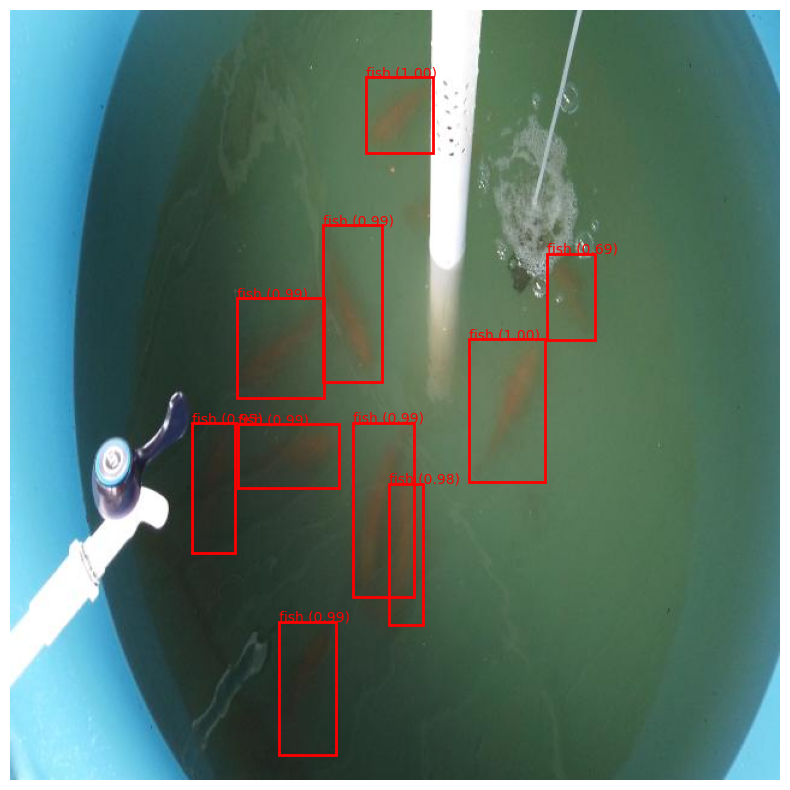

In [26]:
import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.datasets import CocoDetection
from torchvision.transforms import functional as F
import matplotlib.pyplot as plt
from PIL import Image

# Load Faster R-CNN with ResNet-50 backbone
def get_model(num_classes):
    # Load pre-trained Faster R-CNN
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # Replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


# Initialize the model
num_classes = 2  # Background + chair + person + table

# Move model to GPU if available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')


# Load the trained model
model = get_model(num_classes)
model.load_state_dict(torch.load("C:/Users/User/fasterrcnn_result/fasterrcnn_resnet50_epoch_2.pth"))
model.to(device)
model.eval()  # Set the model to evaluation mode


def prepare_image(image_path):
    image = Image.open(image_path).convert("RGB")  # Open image
    image_tensor = F.to_tensor(image).unsqueeze(0)  # Convert image to tensor and add batch dimension
    return image_tensor.to(device)



# Load the unseen image
image_path = "C:/Users/User/dataset/test/1005.jpg"
image_tensor = prepare_image(image_path)

with torch.no_grad():  # Disable gradient computation for inference
    prediction = model(image_tensor)

# `prediction` contains:
# - boxes: predicted bounding boxes
# - labels: predicted class labels
# - scores: predicted scores for each box (confidence level)
COCO_CLASSES = {0: "Background", 1: "fish"}

def get_class_name(class_id):
    return COCO_CLASSES.get(class_id, "Unknown")
    
# Draw bounding boxes with the correct class names and increase image size
def draw_boxes(image, prediction, fig_size=(10, 10)):
    boxes = prediction[0]['boxes'].cpu().numpy()  # Get predicted bounding boxes
    labels = prediction[0]['labels'].cpu().numpy()  # Get predicted labels
    scores = prediction[0]['scores'].cpu().numpy()  # Get predicted scores
    
    # Set a threshold for showing boxes (e.g., score > 0.5)
    threshold = 0.5
    
    # Set up the figure size to control the image size
    plt.figure(figsize=fig_size)  # Adjust the figure size here

    for box, label, score in zip(boxes, labels, scores):
        if score > threshold:
            x_min, y_min, x_max, y_max = box
            class_name = get_class_name(label)  # Get the class name
            plt.imshow(image)  # Display the image
            plt.gca().add_patch(plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, 
                                              linewidth=2, edgecolor='r', facecolor='none'))
            plt.text(x_min, y_min, f"{class_name} ({score:.2f})", color='r')
    
    plt.axis('off')  # Turn off axis
    plt.show()

# Display the image with bounding boxes and correct labels
draw_boxes(Image.open(image_path), prediction, fig_size=(12, 10))  # Example of increased size

In [28]:
from PIL import Image, ImageDraw, ImageFont

image_folder = "C:/Users/User/dataset/test"  # Path to your folder with test images
output_folder = "C:/Users/User/dataset/result"  # Where to save output images
os.makedirs(output_folder, exist_ok=True)

# Load model
def get_model(num_classes):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=False)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

num_classes = 2  # Background + fish
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_model(num_classes)
model.load_state_dict(torch.load("C:/Users/User/fasterrcnn_result/fasterrcnn_resnet50_epoch_2.pth"))
model.to(device)
model.eval()

# Class names
COCO_CLASSES = {0: "Background", 1: "fish"}
def get_class_name(class_id):
    return COCO_CLASSES.get(class_id, "Unknown")

# Process a single image
def predict_and_draw(image_path, save_output=True):
    image = Image.open(image_path).convert("RGB")
    image_tensor = F.to_tensor(image).unsqueeze(0).to(device)

    with torch.no_grad():
        prediction = model(image_tensor)

    boxes = prediction[0]["boxes"].cpu()
    labels = prediction[0]["labels"].cpu()
    scores = prediction[0]["scores"].cpu()

    draw = ImageDraw.Draw(image)
    threshold = 0.5

    for box, label, score in zip(boxes, labels, scores):
        if score >= threshold:
            x0, y0, x1, y1 = box.tolist()
            class_name = get_class_name(label.item())
            draw.rectangle([x0, y0, x1, y1], outline="red", width=3)
            draw.text((x0, y0), f"{class_name} {score:.2f}", fill="red")

    if save_output:
        output_path = os.path.join(output_folder, os.path.basename(image_path))
        image.save(output_path)
    else:
        image.show()

# Loop through all images
supported_formats = (".jpg", ".jpeg", ".png")
for filename in os.listdir(image_folder):
    if filename.lower().endswith(supported_formats):
        image_path = os.path.join(image_folder, filename)
        print(f"🔍 Processing: {filename}")
        predict_and_draw(image_path)

C:\Users\User\AppData\Local\Temp\ipykernel_2500\2359036262.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("C:/Users/User/fasterrcnn_re

🔍 Processing: 1005.jpg
🔍 Processing: 1007_png.rf.9d8fc7dd299b4201b12d7350c71591b4.jpg
🔍 Processing: 1029_png.rf.a9ff3c1f9252addbb69f8351da10c934.jpg
🔍 Processing: 1098_png.rf.d45882249c8ca53c61bb0c214bc81e59.jpg
🔍 Processing: 1112_png.rf.5efacaf7be331aadf3bba043e63ec759.jpg
🔍 Processing: 1125_png.rf.d2095e523bbf50e95ea31805c48dcefd.jpg
🔍 Processing: 1136_png.rf.f28524ec73a3e2ed686e1f6cddff561a.jpg
🔍 Processing: 1141_png.rf.f5509ea4e6cbe7ebe482df2574bd90e3.jpg
🔍 Processing: 1174_png.rf.b23af5f375c34d8d7624bcf51e3a525e.jpg
🔍 Processing: 1212_png.rf.e08296911f0659985de468b7b39ffe7b.jpg
🔍 Processing: 2019_png.rf.13fa65514387e2e25bfbe359c274db75.jpg
🔍 Processing: 2025_png.rf.01d958353f6b866453c90b532d2da9fd.jpg
🔍 Processing: 2046_png.rf.65533208e4705e6794fd249c296122bd.jpg
🔍 Processing: 2062_png.rf.8f277eddb9743722bf97e86d451beac3.jpg
🔍 Processing: 2087_png.rf.93ebff2fde478cf0fe1a3b31f177d5c6.jpg
🔍 Processing: 2099_png.rf.09ee6f70a9d53038c19d11fbd5910468.jpg
🔍 Processing: 2106_png.rf.244cb3

In [31]:
import cv2
import torch
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.transforms import functional as F
from PIL import Image, ImageDraw, ImageFont
import numpy as np

# Load model
def get_model(num_classes):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=False)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

num_classes = 2  # background + fish
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_model(num_classes)
model.load_state_dict(torch.load("C:/Users/User/fasterrcnn_result/fasterrcnn_resnet50_epoch_2.pth"))
model.to(device)
model.eval()

# Class names
COCO_CLASSES = {0: "Background", 1: "fish"}
def get_class_name(class_id):
    return COCO_CLASSES.get(class_id, "Unknown")

# Process one frame
def process_frame(frame):
    pil_img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    tensor = F.to_tensor(pil_img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(tensor)

    boxes = outputs[0]["boxes"].cpu().numpy()
    labels = outputs[0]["labels"].cpu().numpy()
    scores = outputs[0]["scores"].cpu().numpy()

    fish_count = sum(1 for label, score in zip(labels, scores) if label == 1 and score > 0.5)

    for box, label, score in zip(boxes, labels, scores):
        if score > 0.5:
            x1, y1, x2, y2 = box.astype(int)
            class_name = get_class_name(label)
            if label == 1:  # class 'fish'
                fish_count += 1
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(frame, f"{class_name} {score:.2f}", (x1, y1 - 5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # Draw total count on frame
    cv2.putText(frame, f"Fish Count: {fish_count}", (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 0, 0), 2)

    return frame

# Video input/output paths
video_path = "C:/Users/User/dataset/test/video/1.mp4"
output_path = "C:/Users/User/dataset/result/1005_2.mp4"

# Open input video
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Define video writer
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

print("🎥 Processing video...")
frame_count = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    processed_frame = process_frame(frame)
    out.write(processed_frame)

    frame_count += 1
    if frame_count % 10 == 0:
        print(f"Processed {frame_count} frames...")

cap.release()
out.release()
print("✅ Done! Saved to:", output_path)


C:\Users\User\AppData\Local\Temp\ipykernel_2500\50684417.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("C:/Users/User/fasterrcnn_resu

🎥 Processing video...
Processed 10 frames...
Processed 20 frames...
Processed 30 frames...
Processed 40 frames...
Processed 50 frames...
Processed 60 frames...
Processed 70 frames...
Processed 80 frames...
Processed 90 frames...
Processed 100 frames...
Processed 110 frames...
Processed 120 frames...
Processed 130 frames...
Processed 140 frames...
Processed 150 frames...
Processed 160 frames...
Processed 170 frames...
Processed 180 frames...
Processed 190 frames...
Processed 200 frames...
Processed 210 frames...
Processed 220 frames...
Processed 230 frames...
Processed 240 frames...
Processed 250 frames...
Processed 260 frames...
Processed 270 frames...
Processed 280 frames...
Processed 290 frames...
Processed 300 frames...
Processed 310 frames...
Processed 320 frames...
Processed 330 frames...
Processed 340 frames...
Processed 350 frames...
Processed 360 frames...
Processed 370 frames...
Processed 380 frames...
Processed 390 frames...
Processed 400 frames...
Processed 410 frames...
Pro

In [137]:
import torch
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.transforms import functional as F
from PIL import Image, ImageDraw, ImageFont
import os

# === Model Setup ===
def get_model(num_classes):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

# === Load Model ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 2  # background + fish

model = get_model(num_classes)
model.load_state_dict(torch.load("C:/Users/User/fasterrcnn_result/fasterrcnn_resnet50_epoch_2.pth"))  # update path
model.to(device)
model.eval()

# === Folder Setup ===
image_folder = "C:/Users/User/dataset/test"  # input folder
output_folder = "C:/Users/User/dataset/result2"  # output folder
os.makedirs(output_folder, exist_ok=True)

# === Label Map ===
COCO_CLASSES = {0: "background", 1: "fish"}

# === Font (Optional for labels) ===
try:
    font = ImageFont.truetype("arial.ttf", 16)
except:
    font = ImageFont.load_default()

# === Inference Loop ===
image_files = [f for f in os.listdir(image_folder) if f.lower().endswith((".jpg", ".png", ".jpeg"))]

for image_name in image_files:
    image_path = os.path.join(image_folder, image_name)
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)
    image_tensor = F.to_tensor(image).unsqueeze(0).to(device)

    with torch.no_grad():
        prediction = model(image_tensor)

    boxes = prediction[0]["boxes"].cpu().numpy()
    labels = prediction[0]["labels"].cpu().numpy()
    scores = prediction[0]["scores"].cpu().numpy()

    threshold = 0.5
    fish_count = 0

    for box, label, score in zip(boxes, labels, scores):
        if score > threshold and label == 1:
            fish_count += 1
            x_min, y_min, x_max, y_max = box
            draw.rectangle([x_min, y_min, x_max, y_max], outline="red", width=2)
            draw.text((x_min, y_min - 10), f"fish ({score:.2f})", fill="red", font=font)

    # Draw fish count
    draw.text((10, 10), f"Fish Count: {fish_count}", fill="blue", font=font)

    # Save the result
    output_path = os.path.join(output_folder, image_name)
    image.save(output_path)
    print(f"{image_name} -> Fish Count: {fish_count} (saved to {output_path})")


C:\Users\User\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\User\AppData\Local\Temp\ipykernel_2500\2110859600.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitr

1005_png.rf.a028d6867558e274105661138d311dda.jpg -> Fish Count: 10 (saved to C:/Users/User/dataset/result2\1005_png.rf.a028d6867558e274105661138d311dda.jpg)
1007_png.rf.9d8fc7dd299b4201b12d7350c71591b4.jpg -> Fish Count: 10 (saved to C:/Users/User/dataset/result2\1007_png.rf.9d8fc7dd299b4201b12d7350c71591b4.jpg)
1029_png.rf.a9ff3c1f9252addbb69f8351da10c934.jpg -> Fish Count: 10 (saved to C:/Users/User/dataset/result2\1029_png.rf.a9ff3c1f9252addbb69f8351da10c934.jpg)
1098_png.rf.d45882249c8ca53c61bb0c214bc81e59.jpg -> Fish Count: 10 (saved to C:/Users/User/dataset/result2\1098_png.rf.d45882249c8ca53c61bb0c214bc81e59.jpg)
1112_png.rf.5efacaf7be331aadf3bba043e63ec759.jpg -> Fish Count: 10 (saved to C:/Users/User/dataset/result2\1112_png.rf.5efacaf7be331aadf3bba043e63ec759.jpg)
1125_png.rf.d2095e523bbf50e95ea31805c48dcefd.jpg -> Fish Count: 9 (saved to C:/Users/User/dataset/result2\1125_png.rf.d2095e523bbf50e95ea31805c48dcefd.jpg)
1136_png.rf.f28524ec73a3e2ed686e1f6cddff561a.jpg -> Fish Co

C:\Users\User\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\User\AppData\Local\Temp\ipykernel_2500\4214486307.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pyt

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


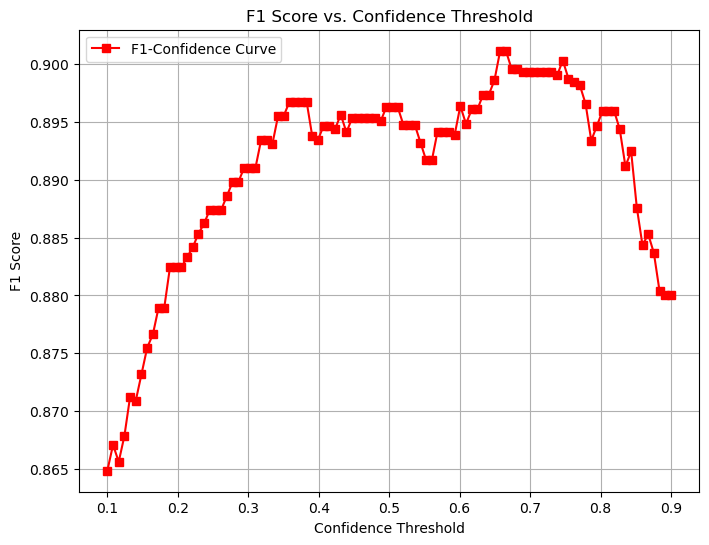

In [143]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.ops import box_iou
from pycocotools.coco import COCO
from PIL import Image
import os
from torchvision.transforms import functional as F

# Load Faster R-CNN model
model = get_model(num_classes)
model.load_state_dict(torch.load("C:/Users/User/fasterrcnn_result/fasterrcnn_resnet50_epoch_2.pth"))
model.to(device)
model.eval()

# Load COCO ground truth annotations
coco_gt = COCO("C:/Users/User/dataset/test/annotations/_annotations.coco.json")

# Image directory
image_dir = "C:/Users/User/dataset/test"
output_dir = "C:/Users/User/dataset/result4"
os.makedirs(output_dir, exist_ok=True)

# IoU Threshold for Matching
IOU_THRESHOLD = 0.5

# Confidence Score Thresholds to evaluate
conf_thresholds = np.linspace(0.1, 0.9, 100)  # 10 confidence levels from 0.1 to 0.9

# Store results
precision_list = []
recall_list = []
f1_list = []

def compute_iou(boxes1, boxes2):
    """Compute Intersection over Union (IoU) between two sets of boxes."""
    if len(boxes1) == 0 or len(boxes2) == 0:
        return torch.zeros(0, dtype=torch.float32)
    return box_iou(boxes1, boxes2)

# Process images
for conf_threshold in conf_thresholds:
    total_tp, total_fp, total_fn = 0, 0, 0

    for img_id in coco_gt.getImgIds():
        img_info = coco_gt.loadImgs(img_id)[0]
        img_path = os.path.join(image_dir, img_info["file_name"])

        # Load image
        image = Image.open(img_path).convert("RGB")
        img_tensor = F.to_tensor(image).unsqueeze(0).to(device)

        # Get ground truth bounding boxes
        ann_ids = coco_gt.getAnnIds(imgIds=img_id)
        annotations = coco_gt.loadAnns(ann_ids)

        gt_boxes = []
        for ann in annotations:
            x, y, w, h = ann["bbox"]
            gt_boxes.append([x, y, x + w, y + h])  # Convert to [x1, y1, x2, y2]

        gt_boxes = torch.tensor(gt_boxes, dtype=torch.float32).to(device)

        # Run Faster R-CNN detection
        with torch.no_grad():
            predictions = model(img_tensor)[0]

        pred_boxes = predictions["boxes"].to(device)
        pred_scores = predictions["scores"].to(device)


        # Apply confidence threshold
        keep = pred_scores > conf_threshold
        pred_boxes = pred_boxes[keep]

        # Match predictions with ground truth using IoU
        ious = compute_iou(pred_boxes, gt_boxes)

        tp, fp, fn = 0, 0, len(gt_boxes)

        for iou_row in ious:
            if iou_row.max() > IOU_THRESHOLD:
                tp += 1  # True Positive
                fn -= 1  # Correct detection
            else:
                fp += 1  # False Positive

        # Accumulate results
        total_tp += tp
        total_fp += fp
        total_fn += fn

    # Compute Precision & Recall
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall + 1e-6)  # Avoid division by zero

    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1_score)

# Convert lists to numpy arrays
precision_array = np.array(precision_list)
recall_array = np.array(recall_list)
f1_array = np.array(f1_list)

# Plot F1-Confidence Curve
plt.figure(figsize=(8, 6))
plt.plot(conf_thresholds, f1_array, marker='s', linestyle='-', color='r', label="F1-Confidence Curve")
plt.xlabel("Confidence Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs. Confidence Threshold")
plt.legend()
plt.grid(True)
plt.show()


In [354]:
import torch
import numpy as np
from torchvision.ops import box_iou
from pycocotools.coco import COCO
from sklearn.metrics import confusion_matrix
import os
from PIL import Image
from torchvision.transforms import functional as F

# Load model
model = get_model(num_classes=2)
model.load_state_dict(torch.load("C:/Users/User/fasterrcnn_result/fasterrcnn_resnet50_epoch_2.pth"))
model.to(device)
model.eval()

# Load COCO annotations
coco_gt = COCO("C:/Users/User/dataset/valid/annotations/_annotations.coco.json")
image_dir = "C:/Users/User/dataset/valid"

IOU_THRESHOLD = 0.5
CONF_THRESHOLD = 0.5

y_true = []
y_pred = []

for img_id in coco_gt.getImgIds():
    img_info = coco_gt.loadImgs(img_id)[0]
    img_path = os.path.join(image_dir, img_info["file_name"])
    image = Image.open(img_path).convert("RGB")
    img_tensor = F.to_tensor(image).unsqueeze(0).to(device)

    # Ground truth
    ann_ids = coco_gt.getAnnIds(imgIds=img_id)
    annotations = coco_gt.loadAnns(ann_ids)

    gt_boxes = []
    gt_labels = []

    for ann in annotations:
        x, y, w, h = ann["bbox"]
        gt_boxes.append([x, y, x+w, y+h])
        gt_labels.append(ann["category_id"])

    gt_boxes = torch.tensor(gt_boxes, dtype=torch.float32).to(device)
    gt_labels = torch.tensor(gt_labels, dtype=torch.int64)

    # Prediction
    with torch.no_grad():
        prediction = model(img_tensor)[0]

    pred_boxes = prediction["boxes"].to(device)
    pred_labels = prediction["labels"].to(device)
    pred_scores = prediction["scores"].to(device)

    keep = pred_scores > CONF_THRESHOLD
    pred_boxes = pred_boxes[keep]
    pred_labels = pred_labels[keep]

    ious = box_iou(pred_boxes, gt_boxes)
    matched_gt = set()

    for i, iou_row in enumerate(ious):
        max_iou = iou_row.max()
        max_idx = iou_row.argmax()

        if max_iou > IOU_THRESHOLD and max_idx.item() not in matched_gt:
            y_true.append(gt_labels[max_idx].item())
            y_pred.append(pred_labels[i].item())
            matched_gt.add(max_idx.item())
        else:
            y_pred.append(pred_labels[i].item())
            y_true.append(0)  # No match — assume background

    # Unmatched GT boxes (false negatives)
    for j in range(len(gt_boxes)):
        if j not in matched_gt:
            y_true.append(gt_labels[j].item())
            y_pred.append(0)  # No prediction

# Build confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=[1, 0])  # background, fish

print("🔢 Confusion Matrix (rows=predicted, cols=actual):")
print(cm)

C:\Users\User\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\User\AppData\Local\Temp\ipykernel_2500\1161026210.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pyt

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
🔢 Confusion Matrix (rows=predicted, cols=actual):
[[412  19]
 [ 51   0]]


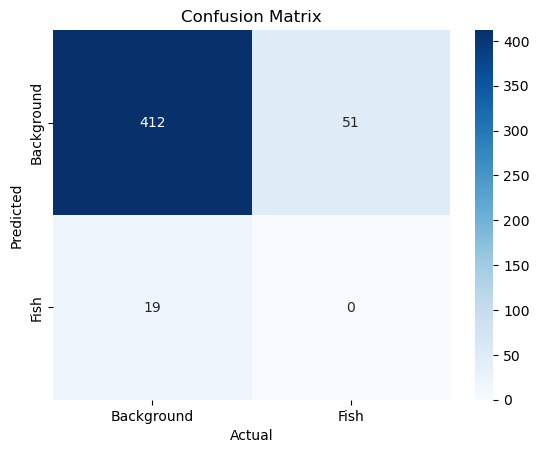

In [317]:
import seaborn as sns
import matplotlib.pyplot as plt

labels = ["Background", "Fish"]
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Confusion Matrix")
plt.show()

In [318]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues", cbar=False)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix50.png", dpi=300)  # Save as PNG
plt.close()

In [355]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred, labels=[1], average='binary')
recall = recall_score(y_true, y_pred, labels=[1], average='binary')
f1 = f1_score(y_true, y_pred, labels=[1], average='binary')
ap = average_precision_score(all_true_labels, all_pred_scores)

print(f"🎯 Mean Average Precision (mAP): {ap:.4f}")
print(f"🎯 Precision: {precision:.3f}")
print(f"📦 Recall: {recall:.3f}")
print(f"📊 F1 Score: {f1:.3f}")

🎯 Mean Average Precision (mAP): 0.9785
🎯 Precision: 0.890
📦 Recall: 0.956
📊 F1 Score: 0.922


In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.ops import box_iou
from pycocotools.coco import COCO
from torchvision.transforms import functional as F
from PIL import Image
import os
from sklearn.metrics import precision_recall_curve, auc

# Load your model
model = get_model(num_classes=2)
model.load_state_dict(torch.load("C:/Users/User/fasterrcnn_result/fasterrcnn_resnet50_epoch_2.pth"))
model.to("cuda")
model.eval()

# Load COCO ground truth
coco_gt = COCO("C:/Users/User/dataset/valid/annotations/_annotations.coco.json")
image_dir = "C:/Users/User/dataset/valid"

# Initialize lists
all_true_labels = []
all_pred_scores = []

IOU_THRESHOLD = 0.5

def compute_iou(boxes1, boxes2):
    if len(boxes1) == 0 or len(boxes2) == 0:
        return torch.zeros((len(boxes1), len(boxes2)))
    return box_iou(boxes1, boxes2)

# Process each image
for img_id in coco_gt.getImgIds():
    img_info = coco_gt.loadImgs(img_id)[0]
    img_path = os.path.join(image_dir, img_info["file_name"])

    image = Image.open(img_path).convert("RGB")
    img_tensor = F.to_tensor(image).unsqueeze(0).to("cuda")

    # Load ground truth
    ann_ids = coco_gt.getAnnIds(imgIds=img_id)
    annotations = coco_gt.loadAnns(ann_ids)

    gt_boxes = []
    for ann in annotations:
        x, y, w, h = ann["bbox"]
        gt_boxes.append([x, y, x + w, y + h])

    gt_boxes = torch.tensor(gt_boxes, dtype=torch.float32).to("cuda")

    with torch.no_grad():
        pred = model(img_tensor)[0]

    pred_boxes = pred['boxes'].to("cuda")
    pred_scores = pred['scores'].to("cuda")

    matched_gt = torch.zeros(len(gt_boxes))  # Keep track of matched GTs
    for pred_box, score in zip(pred_boxes, pred_scores):
        ious = compute_iou(pred_box.unsqueeze(0), gt_boxes).squeeze(0)
        max_iou, idx = torch.max(ious, dim=0)

        if max_iou >= IOU_THRESHOLD and matched_gt[idx] == 0:
            all_true_labels.append(1)
            matched_gt[idx] = 1  # Mark GT as matched
        else:
            all_true_labels.append(0)

        all_pred_scores.append(score.item())

# Convert to numpy
true_labels = np.array(all_true_labels)
pred_scores = np.array(all_pred_scores)

# Compute precision-recall
precision, recall, _ = precision_recall_curve(true_labels, pred_scores)
pr_auc = auc(recall, precision)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', label=f'Faster R-CNN {pr_auc:.3f} mAP@0.5')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Faster R-CNN)")
plt.legend()
plt.grid(True)
plt.ylim(0, 1)
plt.savefig("precision_recall2.png", dpi=300)  # Save as PNG
plt.close()


C:\Users\User\AppData\Local\Temp\ipykernel_21296\4064060124.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("C:/Users/User/fasterrcnn_r

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [138]:
import numpy as np

# Define the function to calculate MAE and RMSE
def calculate_mae_rmse(ground_truth, predicted_values):
    # Convert the input lists to numpy arrays for easier computation
    ground_truth = np.array(ground_truth)
    predicted_values = np.array(predicted_values)
    
    # Calculate MAE (Mean Absolute Error)
    mae = np.mean(np.abs(ground_truth - predicted_values))
    
    # Calculate RMSE (Root Mean Squared Error)
    rmse = np.sqrt(np.mean((ground_truth - predicted_values) ** 2))
    
    return mae, rmse

# Example ground truth and predicted values (you will replace these with your own data)
ground_truth = [10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 20, 20, 20, 20, 20, 20, 20, 30, 30, 30, 30, 30, 30]  # Replace with your actual ground truth
predicted_values = [10, 10, 10, 10, 10, 9, 10, 8, 11, 9, 18, 18, 16, 19, 17, 20, 20, 24, 20, 23, 24, 29, 20]  # Replace with your predicted values

# Calculate MAE and RMSE
mae, rmse = calculate_mae_rmse(ground_truth, predicted_values)

# Print the results
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")


Mean Absolute Error (MAE): 2.4782608695652173
Root Mean Squared Error (RMSE): 3.9727331518303837


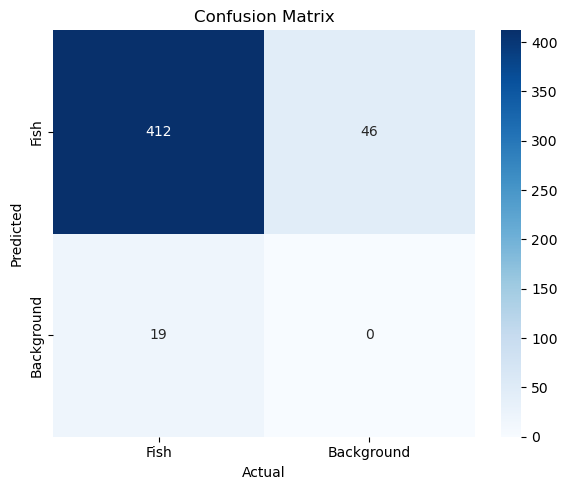

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Replace these with your actual values
TP = 412  # True Positives
FP = 46   # False Positives
FN = 19   # False Negatives

# Generate label vectors
y_true = [1] * TP + [1] * FN + [0] * FP  # Actual labels
y_pred = [1] * TP + [0] * FN + [1] * FP  # Predicted labels

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=[1, 0])

# Transpose the matrix to flip axes
cm_flipped = cm.T  # Now rows are predictions, columns are actual

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm_flipped, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fish", "Background"],
            yticklabels=["Fish", "Background"])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrixyolo.png", dpi=300)  # Save as PNG
plt.show()

